In [2]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./trajopt/constraint.jl")
include("./trajopt/costfunction.jl")
include("./trajopt/scaling.jl")
include("./trajopt/scp.jl")
include("./trajopt/discretize.jl")

discretize_foh

In [3]:
ix = 12
iu = 6
N = 5
dynamics = Rocket()

Rocket(12, 6, 0, 2.0, 0.29292, 0.29292, 0.0025, 0.25, 1.625, 34, [6 6 … 2 2], 9, 68, 18, 9, 18, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0], #undef, #undef, #undef, #undef, #undef)

In [4]:
pdg_const = PDG()
list_const = [pdg_const];

In [5]:
xi = [5,5,5, 0,0,-1, deg2rad(0),deg2rad(0),0, 0,0,0]
xf = [0,0,0, 0,0,0, 0,0,0, 0,0,0];
@assert length(xi) == ix
@assert length(xf) == ix

In [6]:
x0 = zeros(ix,N+1);
u0 = 0.0*ones(iu,N+1);
u0[3,:] .= 1.625 * 2
tf0 = 7.0;
dt0 = tf0/N*ones(N);
for i = 1:N+1
    x0[:,i] = (N-i+1)/N*xi+(i-1)/N*xf;
end
print_jl(x0)
print_jl(u0)

Type is Matrix{Float64}
Shape is (12, 6)
Type is Matrix{Float64}
Shape is (6, 6)


In [7]:
xmin = [0,0,0, 0,0,0, 0,0,0, 0,0,0];
xmax = [5,5,5, 1,1,1, deg2rad(20),deg2rad(20),deg2rad(20), deg2rad(20),deg2rad(20),deg2rad(20)];
umin = [0,0,0, 0,0,0];
umax = [5,5,5, 0.01,0.01,0.01];
min_dt = 3 / N;
max_dt = 15 / N;
scaler = Scaling(xmin, xmax, umin, umax, 0,tf0,min_dt,max_dt)
@assert max_dt * N >= tf0 

In [8]:
max_iter = 200;
w_tf = 2*1e-2;
w_c = 0.0;
w_rate = 1e-2;
w_param = 0.0;
w_vc = 1e2;
w_tr::Float64 = 1e-1;
tol_vc = 1e-6;
tol_tr = 1e-4;
tol_dyn = 1e-1;
tr_norm = "quad";
verbosity = true;
type_tf_free = "tf_free"

"tf_free"

In [9]:
ptr = PTR(N,tf0,max_iter,dynamics,list_const,scaler,
    w_tf,w_c,w_rate,w_param,w_vc,w_tr,
    tol_vc,tol_tr,tol_dyn,
    tr_norm,verbosity,
    type_tf_free=type_tf_free)

PTR(Rocket(12, 6, 0, 2.0, 0.29292, 0.29292, 0.0025, 0.25, 1.625, 34, [6 6 … 2 2], 9, 68, 18, 9, 18, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0], #undef, #undef, #undef, #undef, #undef), Constraint[PDG(2.0, 0.3490658503988659, 0.3490658503988659, 1.5707963267948966, 1.5, 5.0, 0.0, 0.3490658503988659)], Scaling([5.0 0.0 … 0.0 0.0; 0.0 5.0 … 0.0 0.0; … ; 0.0 0.0 … 0.3490658503988659 0.0; 0.0 0.0 … 0.0 0.3490658503988659], [0.2 0.0 … 0.0 0.0; 0.0 0.2 … 0.0 0.0; … ; 0.0 0.0 … 2.864788975654116 0.0; 0.0 0.0 … 0.0 2.864788975654116], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [5.0 0.0 … 0.0 0.0; 0.0 5.0 … 0.0 0.0; … ; 0.0 0.0 … 0.01 0.0; 0.0 0.0 … 0.0 0.01], [0.2 0.0 … 0.0 0.0; 0.0 0.2 … 0.0 0.0; … ; 0.0 0.0 … 100.0 0.0; 0.0 0.0 … 0.0 100.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0,

In [10]:
run(ptr,x0,u0,dt0,xi,xf,"Gurobi")

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-28
+--------------------------------------------------------------------------------------------------+
|                                   ..:: Penalized Trust Region ::..                               |
+-------+------------+-----------+-----------+-----------+---------+---------+----------+----------+
| iter. |    cost    |    tof    |   main    |   rate    |  param  | log(vc) | log(tr)  | log(dyn) |
+-------+------------+-----------+-----------+-----------+---------+---------+----------+----------+
|1      |32.18       |8.783     |0.000      |1.352      |-1.000    |-0.5     | 1.2      |-1.8e-02   |
|2      |0.22        |7.399     |0.000      |1.049      |-1.000    |-6.6     | -0.2     |-6.9e-01   |
|3      |0.18        |7.458     |0.000      |0.845      |-1.000    |-7.3     | -0.6     |-1.8e+00   |
|4      |0.16        |7.462     |0.000      |0.833      |-1.000    |-7.0     | -2.5     |-3.7e+00 

true

In [11]:
Fnorm = []
Tnorm = []
vnorm = []
wnorm = []
gamma = []
delta = []
for i = 1:ptr.N+1
    append!(Fnorm,norm(ptr.solution.u[1:3,i]))
    append!(Tnorm,norm(ptr.solution.u[4:6,i],Inf))
    append!(vnorm,norm(ptr.solution.x[4:6,i]))
    append!(wnorm,norm(ptr.solution.x[10:12,i]))
    append!(gamma,atan(ptr.solution.x[3,i]/norm(ptr.solution.x[1:2,i])))
    append!(delta,acos(ptr.solution.u[3,i]/norm(ptr.solution.u[1:3,i])))
end
zquiver = zeros(3, ptr.N+1)
Fquiver = zeros(3, ptr.N+1)
for i = 1:ptr.N+1
    phi = ptr.solution.x[7,i]
    theta = ptr.solution.x[8,i]
    psi = ptr.solution.x[9,i]
    C_B_I = [cos(psi)*cos(theta) sin(psi)*cos(theta) -sin(theta);
    -sin(psi)*cos(phi)+cos(psi)*sin(theta)*sin(phi) cos(psi)*cos(phi)+sin(psi)*sin(theta)*sin(phi) cos(theta)*sin(phi);
    sin(psi)*sin(phi) + cos(psi)*sin(theta)*cos(phi) -cos(psi)*sin(phi)+sin(psi)*sin(theta)*cos(phi) cos(theta)*cos(phi)]
    zquiver[:,i] = C_B_I' * [0,0,1]
    Fquiver[:,i] = C_B_I' * ptr.solution.u[1:3,i]
end

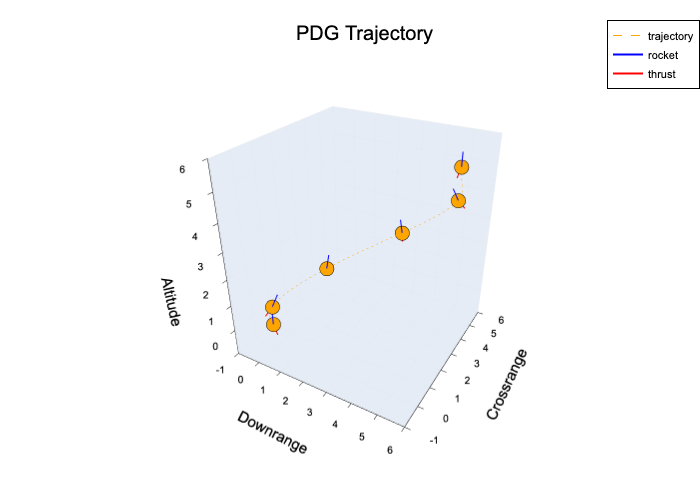

In [12]:
using Plots
plotlyjs()  # Or pyplot() if you prefer
# pyplot()

# Helper to draw 3D vector lines
function draw_vectors!(x, y, z, u, v, w; color=:black, label="", scale=1.0)
    for i in 1:length(x)
        plot3d!(
            [x[i], x[i] + scale * u[i]],
            [y[i], y[i] + scale * v[i]],
            [z[i], z[i] + scale * w[i]],
            color=color,
            label=(i == 1 ? label : ""),  # Only label the first for legend
            linewidth=2
        )
    end
end

# Extract data
x = ptr.solution.x
xprop = ptr.solution.xprop

# Plot setup
plt = plot(size=(800,800), legend=:topright,
           xlabel="Downrange", ylabel="Crossrange", zlabel="Altitude",
           title="PDG Trajectory",
           xlims=(-1, 6), ylims=(-1, 6), zlims=(-1, 6))

# Trajectory points and path
scatter3d!(x[1, :], x[2, :], x[3, :], marker=:circle, color=:orange, label="")
plot3d!(xprop[1, :], xprop[2, :], xprop[3, :], line=(:dash, :orange), label="trajectory")

# Fake 3D quiver using lines
draw_vectors!(
    x[1, :], x[2, :], x[3, :],
    zquiver[1, :], zquiver[2, :], zquiver[3, :],
    color=:blue, label="rocket", scale=0.5)

draw_vectors!(
    x[1, :], x[2, :], x[3, :],
    -Fquiver[1, :], -Fquiver[2, :], -Fquiver[3, :],
    color=:red, label="thrust", scale=0.1
)
# View
# Plots.camera!(plt, (azimuth=-60, elevation=20))
display(plt)


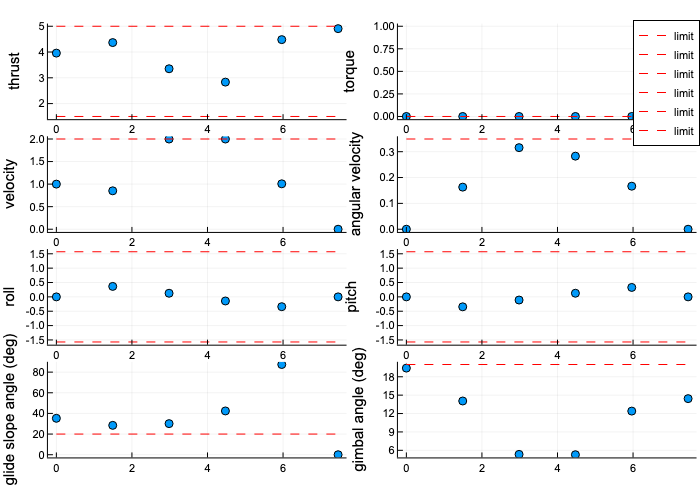

In [13]:
t = ptr.solution.t
const1 = ptr.constraint[1]

# Create a 10-row layout (only 8 used)
plt = plot(layout = (4, 2), size=(800, 500))  # figsize in pixels

# 1. Thrust
plot!(plt[1], t, Fnorm, seriestype=:scatter, label="", marker=:circle)
plot!(plt[1], t, const1.Fmax .* ones(length(t)), linestyle=:dash, color=:red, label="")
plot!(plt[1], t, const1.Fmin .* ones(length(t)), linestyle=:dash, color=:red, label="")
ylabel!(plt[1], "thrust")

# 2. Torque
plot!(plt[2], t, Tnorm, seriestype=:scatter, marker=:circle, label="")
plot!(plt[2], t, const1.tau_max .* ones(length(t)), linestyle=:dash, color=:red, label="")
ylabel!(plt[2], "torque")

# 3. Velocity
plot!(plt[3], t, vnorm, seriestype=:scatter, marker=:circle, label="")
plot!(plt[3], t, const1.vmax .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
ylabel!(plt[3], "velocity")

# 4. Angular velocity
plot!(plt[4], t, wnorm, seriestype=:scatter, marker=:circle, label="")
plot!(plt[4], t, const1.wmax .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
ylabel!(plt[4], "angular velocity")

# 5. Roll
plot!(plt[5], t, ptr.solution.x[7, :], seriestype=:scatter, marker=:circle, label="")
plot!(plt[5], t, const1.theta_max .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
plot!(plt[5], t, -const1.theta_max .* ones(length(t)), linestyle=:dash, color=:red, label="")
ylabel!(plt[5], "roll")

# 6. Pitch
plot!(plt[6], t, ptr.solution.x[8, :], seriestype=:scatter, marker=:circle, label="")
plot!(plt[6], t, const1.theta_max .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
plot!(plt[6], t, -const1.theta_max .* ones(length(t)), linestyle=:dash, color=:red, label="")
ylabel!(plt[6], "pitch")

# 7. Glide slope angle (deg)
plot!(plt[7], t, rad2deg.(gamma), seriestype=:scatter, marker=:circle, label="")
plot!(plt[7], t, rad2deg(const1.gamma_s) .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
ylabel!(plt[7], "glide slope angle (deg)")

# 8. Gimbal angle (deg)
plot!(plt[8], t, rad2deg.(delta), seriestype=:scatter, marker=:circle, label="")
plot!(plt[8], t, rad2deg(const1.delta_max) .* ones(length(t)), linestyle=:dash, color=:red, label="limit")
ylabel!(plt[8], "gimbal angle (deg)")

display(plt)

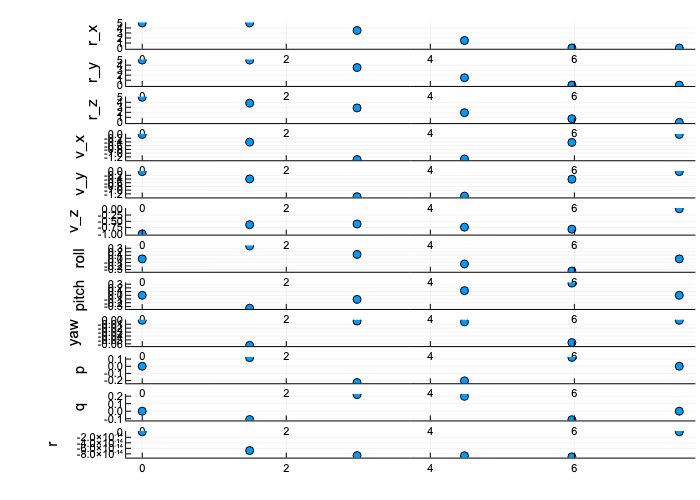

In [14]:
t = ptr.solution.t
const1 = ptr.constraint[1]

# Create a 10-row layout (only 8 used)
plt = plot(layout = (12, 1), size=(600, 800))  # figsize in pixels

input_name_list = ["r_x","r_y","r_z","v_x","v_y","v_z","roll","pitch","yaw","p","q","r"]

for idx = 1:12
    # 1. Thrust
    plot!(plt[idx], t, ptr.solution.x[idx,:], seriestype=:scatter, label="", marker=:circle)
    ylabel!(plt[idx], input_name_list[idx])
end

display(plt)

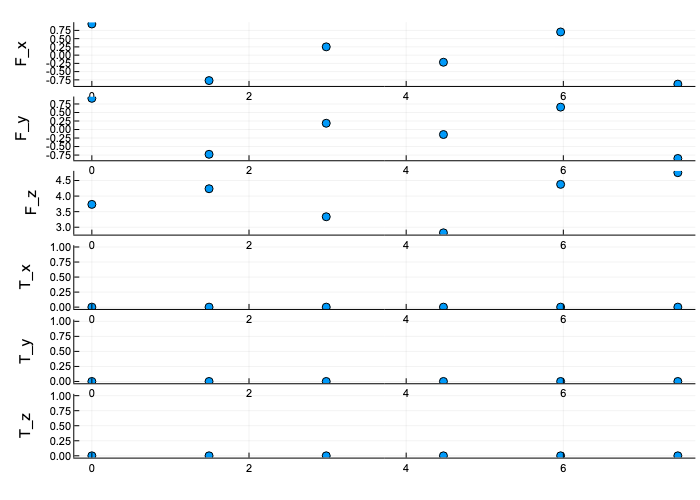

In [15]:
t = ptr.solution.t
const1 = ptr.constraint[1]

# Create a 10-row layout (only 8 used)
plt = plot(layout = (6, 1), size=(600, 800))  # figsize in pixels

input_name_list = ["F_x","F_y","F_z","T_x","T_y","T_z"]

for idx = 1:6
    # 1. Thrust
    plot!(plt[idx], t, ptr.solution.u[idx,:], seriestype=:scatter, label="", marker=:circle)
    # plot!(plt[idx], t, const1.Fmax .* ones(length(t)), linestyle=:dash, color=:red, label="")
    # plot!(plt[idx], t, const1.Fmin .* ones(length(t)), linestyle=:dash, color=:red, label="")
    ylabel!(plt[idx], input_name_list[idx])
end

display(plt)

In [16]:
using JLD2, FileIO
my_dict = Dict("x" => ptr.solution.x, "u" => ptr.solution.u, "t" => ptr.solution.t)
@save "./data/nominal_traj_lunar_landing_N" * string(N) my_dict